### Pre

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error, r2_score
from scipy.optimize import curve_fit
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures

from sklearn.metrics import mean_squared_error, r2_score
import matplotlib
import pandas as pd

from numpy.polynomial.polynomial import Polynomial

In [5]:
def exponential(x, a, b, c):
    return a * np.exp(b * x) + c

In [4]:
# Load the data (replace this with your CSV data loading method)
df = pd.read_csv('/mnt/data/HarmonyBatch/GPU_profiling_batches_1_to_24.csv')  # Update with your CSV file path
# df = df[df['Batch_size'] == 1]  # Filter only batch size = 1
# df = df[df['total_latency']]
# Group data by 'vCPU' and calculate the average of 'Min_latency(ms)' across different 'Memory' configurations
df_avg_latency = df.groupby('batch')['Total_latency(ms)'].mean().reset_index()
# df_avg_latency = df.loc[df.groupby('vCPU')['Memory'].idxmin()].groupby('vCPU').apply(lambda x: x.loc[x['Min_latency(ms)'].idxmin()])

# Now you have the average minimum latency for each vCPU across different memory configurations
X = df_avg_latency['batch'].values.reshape(-1, 1)
y = df_avg_latency['Total_latency(ms)'].values

# Polynomial Regression (degree 2)
poly = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(X)
poly_model = LinearRegression()
poly_model.fit(X_poly, y)
y_pred_poly = poly_model.predict(X_poly)

In [8]:
def fit_latency_vs_batch_size(
    file_path="/mnt/data/HarmonyBatch/GPU_profiling_batches_1_to_32.csv", 
    attribute='Total_latency(ms)'
):
    """
    Fits and plots latency (total or per-worker) vs batch size
    using both linear and 2nd-degree polynomial regression.
    
    Parameters:
    - file_path: path to GPU profiling CSV
    - attribute: the column name to model (e.g., 'Total_latency(ms)', 'Worker_1_lat(ms)')
    """
    # Load and prepare data
     # Load data
    df = pd.read_csv(file_path)
    df_avg = df.groupby('batch')[attribute].mean().reset_index()

    X = df_avg['batch'].values.reshape(-1, 1)
    y = df_avg[attribute].values

    # Linear model
    linear_model = LinearRegression()
    linear_model.fit(X, y)
    y_pred_linear = linear_model.predict(X)
    slope = linear_model.coef_[0]
    intercept = linear_model.intercept_
    r2_linear = r2_score(y, y_pred_linear)

    # Polynomial model (2nd degree)
    poly_model = Polynomial.fit(df_avg['batch'], df_avg[attribute], deg=2)
    y_pred_poly = poly_model(df_avg['batch'])
    r2_poly = r2_score(y, y_pred_poly)
    poly_coeffs = poly_model.convert().coef

    # Print results
    print(f"\nModeling '{attribute}' vs Batch Size")
    print("---- Linear Model ----")
    print(f"Equation: latency = {slope:.4f} * batch + {intercept:.2f}")
    print(f"R²: {r2_linear:.4f}")
    print("\n---- Polynomial Model (deg=2) ----")
    print(f"Coefficients (constant, linear, quadratic): {poly_coeffs}")
    print(f"R²: {r2_poly:.4f}")

    # Plotting
    plt.figure(figsize=(10, 6))
    plt.scatter(X, y, color='black', label='Observed Data', zorder=5)
    plt.plot(X, y_pred_linear, label=f'Linear Fit (R²={r2_linear:.2f})', color='blue', linestyle='--')
    plt.plot(X, y_pred_poly, label=f'Polynomial Fit (R²={r2_poly:.2f})', color='green')

    plt.xlabel('Batch Size')
    plt.ylabel(attribute)
    plt.title(f'Latency vs Batch Size: {attribute}')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


Modeling 'total_latency' vs Batch Size
---- Linear Model ----
Equation: latency = 87.6608 * batch + 51.01
R²: 0.9998

---- Polynomial Model (deg=2) ----
Coefficients (constant, linear, quadratic): [ 4.94582837e+01  8.80937681e+01 -1.31754385e-02]
R²: 0.9998


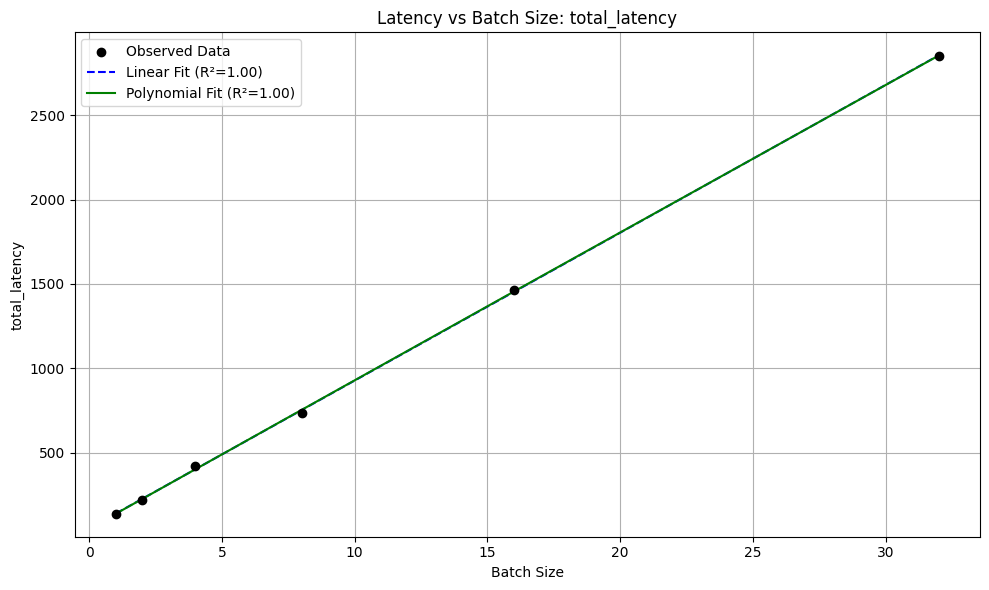

In [9]:
fit_latency_vs_batch_size(attribute='total_latency', file_path="/mnt/data/HarmonyBatch/wrn50-5_gpu_single_mxnet.csv")


Modeling 'Total_latency(ms)' vs Batch Size
---- Linear Model ----
Equation: latency = 74.4981 * batch + 495.15
R²: 0.9985

---- Polynomial Model (deg=2) ----
Coefficients (constant, linear, quadratic): [ 4.80115158e+02  7.81332643e+01 -1.14921271e-01]
R²: 0.9987


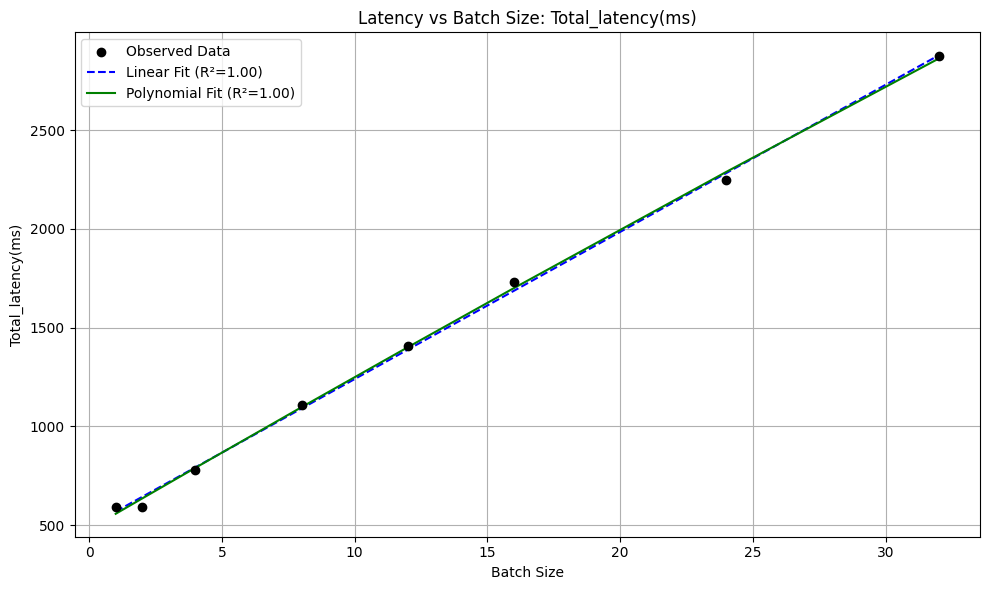

In [16]:
fit_latency_vs_batch_size(attribute='Total_latency(ms)')

In [39]:
def avg_fit_exponential(file_path = '/mnt/data/HarmonyBatch/wrn50_cpu_profiling_batch1_all_configs.csv', 
                    attribute = 'total_latency',
                    batch_size = 1):
    
    df = pd.read_csv(file_path)
    df = df[df['batch_size'] == batch_size]
    df_avg_latency = df.groupby('workers_vCPU')[attribute].max().reset_index()

    X = df_avg_latency['workers_vCPU'].values.reshape(-1, 1)
    y = df_avg_latency[attribute].values
    
        
    params, _ = curve_fit(exponential, X.flatten(), y, p0=[500,   -2.40481306,  120], maxfev=10000)
    y_pred_exp = exponential(X.flatten(), *params)
    mse_exp = mean_squared_error(y, y_pred_exp)
    r2_exp = r2_score(y, y_pred_exp)
    
    print(list(params))
    print("\nExponential Regression Results:")
    print(f"MSE: {mse_exp}")
    print(f"R²: {r2_exp}")

    plt.figure(figsize=(10, 6))
    plt.scatter(X, y, color='black', label='Data', zorder=5)

    # Plot Exponential Regression result
    plt.plot(X, y_pred_exp, color='red', label=f'Exponential Regression (R²={r2_exp:.2f})', zorder=2)

    plt.xlabel('vCPU')
    plt.ylabel('Average Latency (ms)')
    plt.title('Exponential Regression for Latency Prediction')
    plt.legend()
    plt.grid(True)
    plt.show()


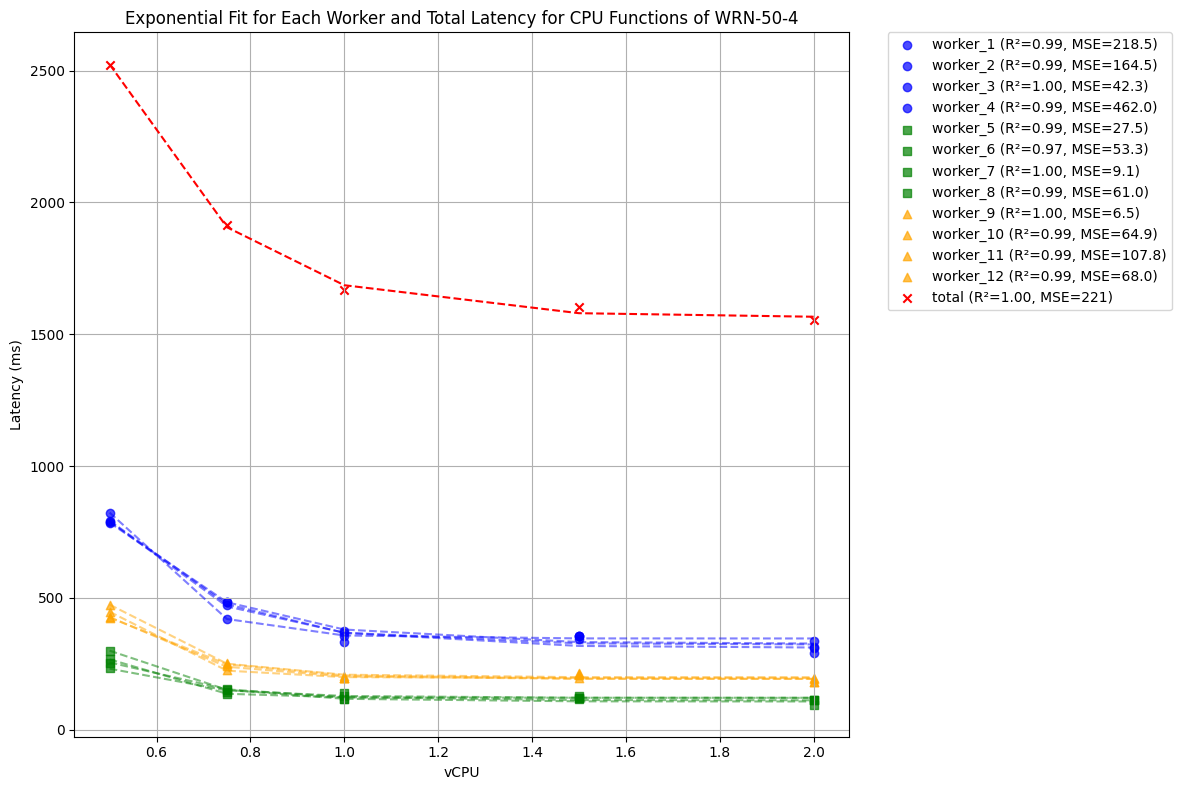

In [54]:
def exponential(x, a, b, c):
    return a * np.exp(b * x) + c

def model_all_workers_and_total(file_path='/mnt/data/HarmonyBatch/wrn50_cpu_profiling_batch1_all_configs.csv', batch_size=1):
    df = pd.read_csv(file_path)
    df = df[df['batch_size'] == batch_size]

    stage_map = {
        'Stage 1': {'range': range(1, 5), 'color': 'blue', 'marker': 'o'},
        'Stage 2': {'range': range(5, 9), 'color': 'green', 'marker': 's'},
        'Stage 3': {'range': range(9, 13), 'color': 'orange', 'marker': '^'},
    }

    plt.figure(figsize=(12, 8))

    for stage_label, props in stage_map.items():
        for i in props['range']:
            col = f'worker_{i}'
            df_avg = df.groupby('workers_vCPU')[col].mean().reset_index()
            X = df_avg['workers_vCPU'].values
            y = df_avg[col].values
            
            try:
                params, _ = curve_fit(exponential, X, y, p0=[500, -2.0, 100], maxfev=10000)
                y_pred = exponential(X, *params)
                r2 = r2_score(y, y_pred)
                mse = mean_squared_error(y, y_pred)
                # plt.scatter(X, y, label=f'{col} (R²={r2:.2f})', marker=props['marker'], color=props['color'], alpha=0.7)
                plt.scatter(
                    X, y, 
                    label=f'{col} (R²={r2:.2f}, MSE={mse:.1f})',
                    marker=props['marker'], 
                    color=props['color'], 
                    alpha=0.7
                )
                
                plt.plot(X, y_pred, color=props['color'], linestyle='--', alpha=0.5)
            except RuntimeError:
                print(f"Fit failed for {col}")

    # Total latency
    df_total = df.groupby('workers_vCPU')['total_latency'].mean().reset_index()
    X_total = df_total['workers_vCPU'].values
    y_total = df_total['total_latency'].values

    try:
        params_total, _ = curve_fit(exponential, X_total, y_total, p0=[500, -2.0, 100], maxfev=10000)
        y_pred_total = exponential(X_total, *params_total)
        r2_total = r2_score(y_total, y_pred_total)
        mse_total = mean_squared_error(y_total, y_pred_total)
        plt.scatter(
            X_total, y_total,
            label=f'total (R²={r2_total:.2f}, MSE={mse_total:.0f})',
            marker='x',
            color='red'
        )
        # plt.scatter(X_total, y_total, label=f'Total Latency (R²={r2_total:.2f})', marker='x', color='red')
        plt.plot(X_total, y_pred_total, color='red', linestyle='--')
    except RuntimeError:
        print("Fit failed for total_latency")

    plt.title('Exponential Fit for Each Worker and Total Latency for CPU Functions of WRN-50-4')
    plt.xlabel('vCPU')
    plt.ylabel('Latency (ms)')
    plt.grid(True)
    plt.legend(loc='upper left', bbox_to_anchor=(1.05, 1), borderaxespad=0.)
    plt.tight_layout()
    plt.show()
    
model_all_workers_and_total()

### SINGLE Functions

[ -1995599.7847941702 , -0.0001738106183263054 , 1998194.5010631285 ]


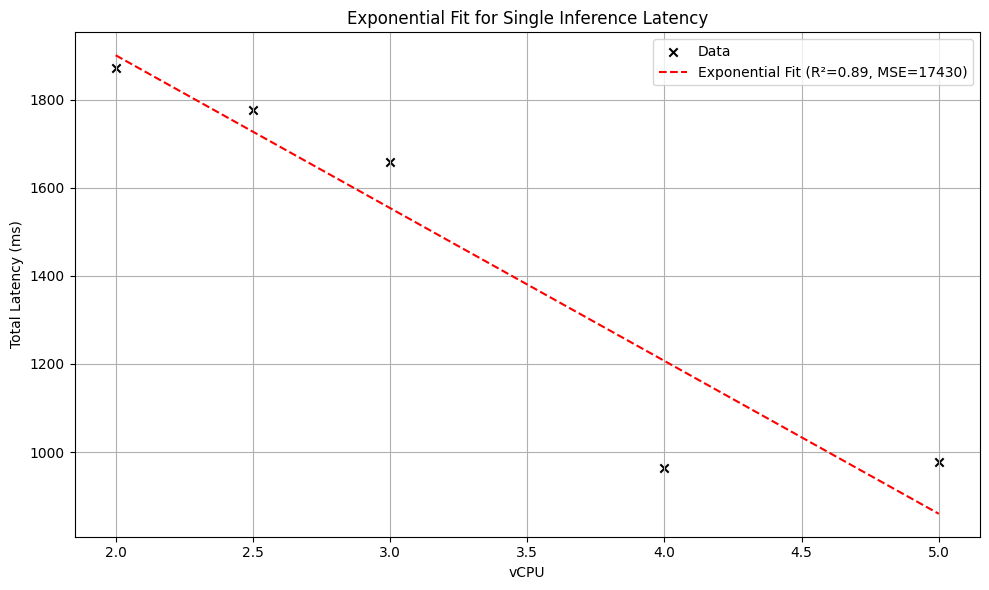

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from sklearn.metrics import r2_score, mean_squared_error

def exponential(x, a, b, c):
    return a * np.exp(b * -x) + c

def model_single_inference_latency(file_path='/mnt/data/HarmonyBatch/single_cw4_mx-v2.csv'):
    # Load and group by vCPU
    df = pd.read_csv(file_path)
    df_avg = df.groupby('vCPU')['total_latency'].mean().reset_index()
    
    X = df_avg['vCPU'].values
    y = df_avg['total_latency'].values

    try:
        # Fit exponential model
        params, _ = curve_fit(exponential, X, y, p0=[5000, -2.0, 1400], maxfev=10000)
        y_pred = exponential(X, *params)
        r2 = r2_score(y, y_pred)
        mse = mean_squared_error(y, y_pred)
        print('[', params[0], ',', params[1], ',', params[2], ']')
        # Plotting
        plt.figure(figsize=(10, 6))
        plt.scatter(X, y, color='black', marker='x', label='Data')
        plt.plot(X, y_pred, color='red', linestyle='--', 
                 label=f'Exponential Fit (R²={r2:.2f}, MSE={mse:.0f})')

        plt.title('Exponential Fit for Single Inference Latency')
        plt.xlabel('vCPU')
        plt.ylabel('Total Latency (ms)')
        plt.grid(True)
        plt.legend(loc='upper right')
        plt.tight_layout()
        plt.show()

    except RuntimeError:
        print("Fit failed for total_latency")

model_single_inference_latency()

In [ ]:
import re
import json
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------------------------
# 1) Parse PDF log
# ---------------------------
def extract_gpu_profiling_from_pdf(pdf_path: str) -> pd.DataFrame:
    # Try PyMuPDF first
    try:
        import fitz  # PyMuPDF
        doc = fitz.open(pdf_path)
        pages_text = [doc.load_page(i).get_text("text") for i in range(doc.page_count)]
        doc.close()
    except Exception:
        import pdfplumber
        pages_text = []
        with pdfplumber.open(pdf_path) as pdf:
            for p in pdf.pages:
                pages_text.append(p.extract_text() or "")

    records = []
    current_batch = None

    for text in pages_text:
        for line in text.splitlines():
            line = line.strip()

            m = re.match(r"^b\s*=\s*(\d+)\s*$", line)
            if m:
                current_batch = int(m.group(1))
                continue

            if "invoke" in line and "http" in line:
                m2 = re.search(r"batch=(\d+)", line)
                current_batch = int(m2.group(1)) if m2 else 1
                continue

            if line.startswith("{") and "infMs" in line:
                try:
                    obj = json.loads(line)
                    inf = float(obj["infMs"])
                    if current_batch is None:
                        current_batch = 1
                    records.append({"batch": int(current_batch), "infMs": inf})
                except Exception:
                    pass

    df = pd.DataFrame(records)
    if df.empty:
        raise ValueError("No (batch, infMs) records extracted from PDF.")
    return df


# ---------------------------
# 2) Outlier removal (IQR per batch)
# ---------------------------
def remove_outliers_iqr_per_batch(df: pd.DataFrame,
                                  value_col: str = "infMs",
                                  group_col: str = "batch",
                                  k: float = 1.5,
                                  min_points: int = 6) -> pd.DataFrame:
    """
    Removes outliers within each batch group using IQR.
    Keeps all points for groups with < min_points samples (too few for stable IQR).
    """
    kept = []

    for b, g in df.groupby(group_col):
        if len(g) < min_points:
            kept.append(g)  # keep as-is
            continue

        q1 = g[value_col].quantile(0.25)
        q3 = g[value_col].quantile(0.75)
        iqr = q3 - q1

        # If iqr==0 (all same), keep everything
        if iqr == 0:
            kept.append(g)
            continue

        lo = q1 - k * iqr
        hi = q3 + k * iqr
        kept.append(g[(g[value_col] >= lo) & (g[value_col] <= hi)])

    return pd.concat(kept, ignore_index=True)


def p99(x):
    return np.percentile(x, 99)

def summarize_by_batch(df: pd.DataFrame) -> pd.DataFrame:
    agg = df.groupby("batch")["infMs"].agg(["count", "mean", p99]).reset_index()
    agg.columns = ["batch", "n", "mean_ms", "p99_ms"]
    return agg.sort_values("batch").reset_index(drop=True)


# ---------------------------
# 3) GPU model (your code)
# ---------------------------
def gpu_pred_mean_ms(batch: int, l1: float, l2: float, G: float,
                     gpu: float = 24, cpu: float = 1,
                     a: float = 1.0, b: float = 0.0) -> float:
    c = min(cpu, 1)
    L = l1 * batch + l2
    return (G / gpu) * (L * a) * 1000.0 + ((L * b) / c) * 1000.0


def gpu_pred_p99_ms(batch: int, l1: float, l2: float, t: float, G: float,
                    gpu: float = 24, cpu: float = 1,
                    a: float = 1.0, b: float = 0.0,
                    scale: float = 1.2) -> float:
    c = min(cpu, 1)
    L = l1 * batch + l2
    L1 = L * a
    n = math.ceil(L1 / (gpu * t))
    tail = ((G - gpu) * n * t + L1) * scale
    return tail * 1000.0 + ((L * b) / c) * 1000.0


def mape(y, yhat) -> float:
    y = np.asarray(y); yhat = np.asarray(yhat)
    return float(np.mean(np.abs((yhat - y) / y)) * 100)


# ---------------------------
# 4) Main: filter batches <8 + remove outliers + plot
# ---------------------------
def plot_gpu_validation_clean(pdf_path: str,
                              out_prefix: str = "wrn50-4_gpu_validation_clean_blt8",
                              l1: float = 0.055, l2: float = 0.080, t: float = 0.002, G: float = 24,
                              gpu: float = 24, cpu: float = 1,
                              a: float = 1.0, b: float = 0.0,
                              p99_scale: float = 1.2,
                              batch_lt: int = 8,
                              iqr_k: float = 1.5):

    df_raw = extract_gpu_profiling_from_pdf(pdf_path)

    # (1) keep only batch < 8
    df = df_raw[df_raw["batch"] < batch_lt].copy()
    if df.empty:
        raise ValueError(f"No samples left after filtering to batch < {batch_lt}.")

    # (2) remove outliers per batch (IQR)
    df_clean = remove_outliers_iqr_per_batch(df, k=iqr_k)

    # (3) aggregate after cleaning
    agg = summarize_by_batch(df_clean)

    # Predictions
    agg["pred_mean_ms"] = agg["batch"].apply(lambda bs: gpu_pred_mean_ms(
        bs, l1=l1, l2=l2, G=G, gpu=gpu, cpu=cpu, a=a, b=b
    ))
    agg["pred_p99_ms"] = agg["batch"].apply(lambda bs: gpu_pred_p99_ms(
        bs, l1=l1, l2=l2, t=t, G=G, gpu=gpu, cpu=cpu, a=a, b=b, scale=p99_scale
    ))

    mean_mape = mape(agg["mean_ms"], agg["pred_mean_ms"])
    p99_mape  = mape(agg["p99_ms"],  agg["pred_p99_ms"])

    # Plot: mean/p99 vs batch
    plt.figure(figsize=(6.5, 3.8))
    plt.plot(agg["batch"], agg["mean_ms"], marker="o", label="Measured mean (cleaned)")
    plt.plot(agg["batch"], agg["p99_ms"],  marker="o", label="Measured p99 (cleaned)")
    plt.plot(agg["batch"], agg["pred_mean_ms"], marker="x", linestyle="--", label="Predicted mean (HB GPU model)")
    plt.plot(agg["batch"], agg["pred_p99_ms"],  marker="x", linestyle="--", label=f"Predicted p99 (scale={p99_scale})")
    plt.xlabel("Batch size")
    plt.ylabel("Inference latency (ms)")
    plt.grid(True, alpha=0.3)
    removed = len(df) - len(df_clean)
    plt.title(f"GPU model validation (warm runs, batch < {batch_lt})\n"
              f"Outliers removed: {removed}/{len(df)} ; MAPE mean={mean_mape:.1f}%, p99={p99_mape:.1f}%")
    plt.legend(fontsize=8)
    plt.tight_layout()
    plt.savefig(f"{out_prefix}_curve.pdf")
    plt.savefig(f"{out_prefix}_curve.png", dpi=200)
    plt.close()

    # Optional: sample-level scatter (cleaned)
    plt.figure(figsize=(6.0, 4.0))
    pred_each = df_clean["batch"].apply(lambda bs: gpu_pred_mean_ms(bs, l1=l1, l2=l2, G=G, gpu=gpu, cpu=cpu, a=a, b=b))
    mx = max(df_clean["infMs"].max(), pred_each.max())
    plt.plot([0, mx], [0, mx], linestyle="--", label="Ideal (y=x)")
    plt.scatter(df_clean["infMs"], pred_each, label="Samples vs predicted mean (cleaned)")
    plt.xlabel("Measured latency (ms)")
    plt.ylabel("Predicted latency (ms)")
    plt.grid(True, alpha=0.3)
    plt.legend(fontsize=9)
    plt.tight_layout()
    plt.savefig(f"{out_prefix}_scatter.pdf")
    plt.savefig(f"{out_prefix}_scatter.png", dpi=200)
    plt.close()

    # Save tables
    agg_out = agg.copy()
    for col in ["mean_ms", "p99_ms", "pred_mean_ms", "pred_p99_ms"]:
        agg_out[col] = agg_out[col].astype(float).round(1)
    agg_out.to_csv(f"{out_prefix}_table.csv", index=False)

    # Save a tiny audit file showing removed points
    df_clean.to_csv(f"{out_prefix}_samples_clean.csv", index=False)
    df_raw.to_csv(f"{out_prefix}_samples_raw.csv", index=False)

    print("Saved:")
    print(f"  {out_prefix}_curve.pdf/.png")
    print(f"  {out_prefix}_scatter.pdf/.png")
    print(f"  {out_prefix}_table.csv")
    print(f"  {out_prefix}_samples_raw.csv")
    print(f"  {out_prefix}_samples_clean.csv")
    print(f"Removed outliers: {removed}/{len(df)} (batch < {batch_lt})")
    print(f"MAPE: mean={mean_mape:.2f}%, p99={p99_mape:.2f}%")
    print(agg_out)


if __name__ == "__main__":
    plot_gpu_validation_clean(
        pdf_path="GPU_profiling.pdf",
        out_prefix="wrn50-4_gpu_validation_clean_blt8",
        l1=0.055, l2=0.080, t=0.002, G=24,
        gpu=24, cpu=1,
        p99_scale=1.2,
        batch_lt=8,
        iqr_k=1.5
    )


ModuleNotFoundError: No module named 'pdfplumber'

parameters for worker1_latency_ms are [1260313.0952024893, -10.800876119529113, 950.7232980512241]
parameters for worker2_latency_ms are [93779.98539243573, -6.721483292593867, 905.3819722097935]
parameters for worker3_latency_ms are [4.2803954328231535e+19, -52.76740336767, 890.9999209470208]
Fit failed for worker4_latency_ms
parameters for worker5_latency_ms are [-189.17739169399573, -2.6014199642640916, 452.4447892396999]
parameters for worker6_latency_ms are [1.674800258197028e+19, -52.82723960175033, 406.9999649192798]


parameters for total_latency are [-1344312.3672018906, 0.00028705503011023357, 1347580.1195880855]
[-0.18269489996613728, 0.6045107489803792, 3.5236596579048647]


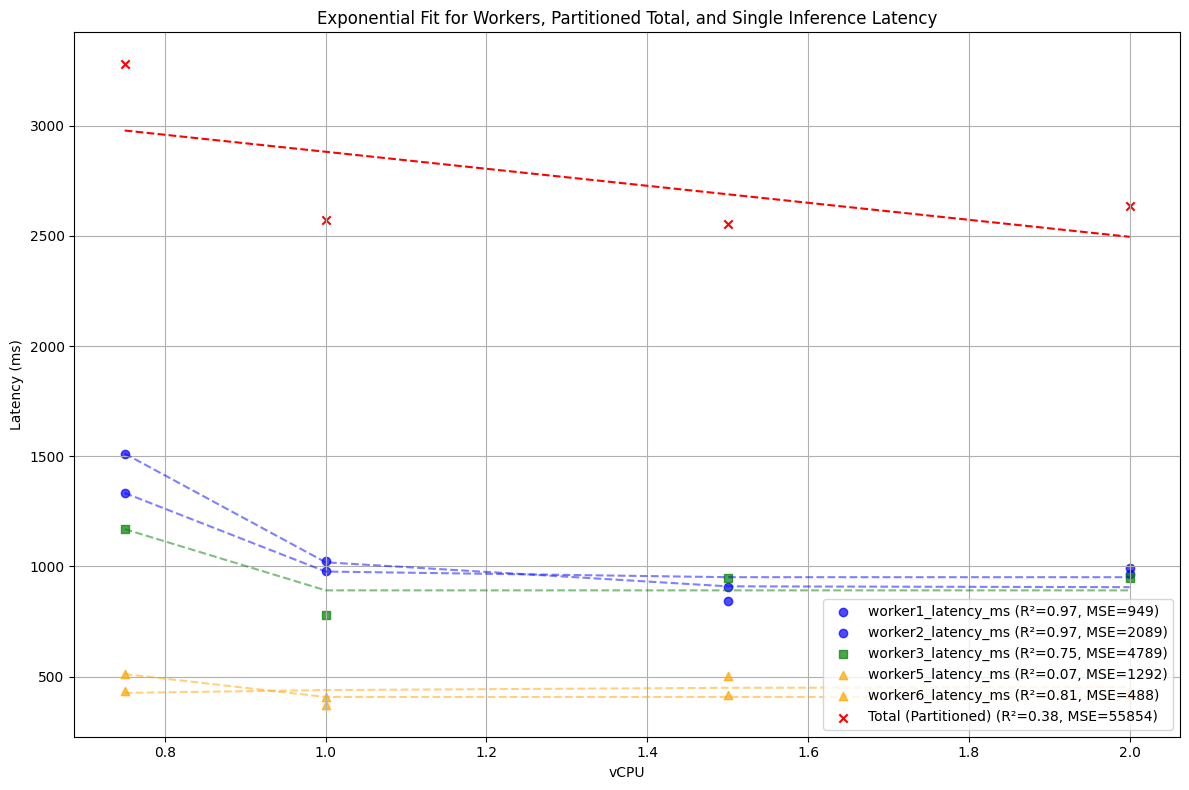

In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from sklearn.metrics import r2_score, mean_squared_error

def exponential(x, a, b, c):
    # return a*np.exp(-x / b) + c
    return a * np.exp(b * x) + c

def model_all_latency_sources(
    
    # partitioned_file="/mnt/data/HarmonyBatch/wrn Final_Partitioned_Latency_Profile.csv",
    partitioned_file="/mnt/data/HarmonyBatch/wrn50-5_w6_partitioned_profiling_new_v2.csv",
    # '/mnt/data/HarmonyBatch/wrn50_cpu_profiling_batch1_all_configs.csv',
    single_file='/mnt/data/HarmonyBatch/wrn50-5_single_mxnet.csv',
    batch_size=1,
    without_batch = False
):
    df = pd.read_csv(partitioned_file)
    if without_batch:
        df['batch_size'] = batch_size
    df = df[df['batch_size'] == batch_size]

    stage_map = {
        'Stage 1': {'range': range(1, 3), 'color': 'blue', 'marker': 'o'},
        'Stage 2': {'range': range(3, 5), 'color': 'green', 'marker': 's'},
        'Stage 3': {'range': range(5, 7), 'color': 'orange', 'marker': '^'},
    }

    plt.figure(figsize=(12, 8))

    # Plot each worker latency
    for stage_label, props in stage_map.items():
        for i in props['range']:
            col = f'worker{i}_latency_ms'
            df_avg = df.groupby('worker1_vcpu')[col].max().reset_index()
            X = df_avg['worker1_vcpu'].values
            y = 1* (df_avg[col].values)

            try:
                params, _ = curve_fit(exponential, X, y, p0=[8000, -1.0, 500], maxfev=10000)
                print('parameters for', col, 'are', list(params))
                y_pred = exponential(X, *params)
                r2 = r2_score(y, y_pred)
                mse = mean_squared_error(y, y_pred)

                plt.scatter(X, y, label=f'{col} (R²={r2:.2f}, MSE={mse:.0f})',
                            marker=props['marker'], color=props['color'], alpha=0.7)
                plt.plot(X, y_pred, linestyle='--', color=props['color'], alpha=0.5)
            except RuntimeError:
                print(f"Fit failed for {col}")

    # Plot total latency from partitioned model
    df_total = df.groupby('worker1_vcpu')['total_latency'].mean().reset_index()
    X_total = df_total['worker1_vcpu'].values
    y_total = df_total['total_latency'].values

    try:
        params_total, _ = curve_fit(exponential, X_total, y_total, p0=[800, 2.0, 2500], maxfev=10000)
        y_pred_total = exponential(X_total, *params_total)
        r2_total = r2_score(y_total, y_pred_total)
        mse_total = mean_squared_error(y_total, y_pred_total)
        print('parameters for total_latency are', list(params_total))
        plt.scatter(X_total, y_total, label=f'Total (Partitioned) (R²={r2_total:.2f}, MSE={mse_total:.0f})',
                    marker='x', color='red')
        plt.plot(X_total, y_pred_total, linestyle='--', color='red')
    except Exception as e:
        print(f"Fit failed for total_latency: {e}")

    # Plot total latency from single inference
    df_single = pd.read_csv(single_file)
    df_single = df_single[df_single['batch_size'] == batch_size]

    df_single_avg = df_single.groupby('vCPU')['total_latency'].mean().reset_index()
    df_single_avg = df_single_avg.sort_values('vCPU')
    X_single = df_single_avg['vCPU'].values
    y_single = df_single_avg['total_latency'].values/1000

    try:
        params_single, _ = curve_fit(exponential, X_single, y_single, p0=[4.710653956393892, 2.4335311937288204, 2.6123285935197663], maxfev=100000)
        # params_single = [4.710653956393892, 2.4335311937288204, 2.6123285935197663]
        y_pred_single = exponential(X_single, *params_single)
        r2_single = r2_score(y_single, y_pred_single)
        mse_single = mean_squared_error(y_single, y_pred_single)
        print(list(params_single))

        # plt.scatter(X_single, y_single, label=f'Single Inference (R²={r2_single:.2f}, MSE={mse_single:.0f})',
        #             marker='D', color='purple')
        # plt.plot(X_single, y_pred_single, linestyle='--', color='purple')
    except RuntimeError:
        print("Fit failed for single inference")

    # Final plot setup
    plt.title('Exponential Fit for Workers, Partitioned Total, and Single Inference Latency')
    plt.xlabel('vCPU')
    plt.ylabel('Latency (ms)')
    plt.grid(True)
    plt.legend(loc='lower right')

    plt.tight_layout()
    plt.show()

model_all_latency_sources(without_batch=True)
# model_all_latency_sources(batch_size=2)

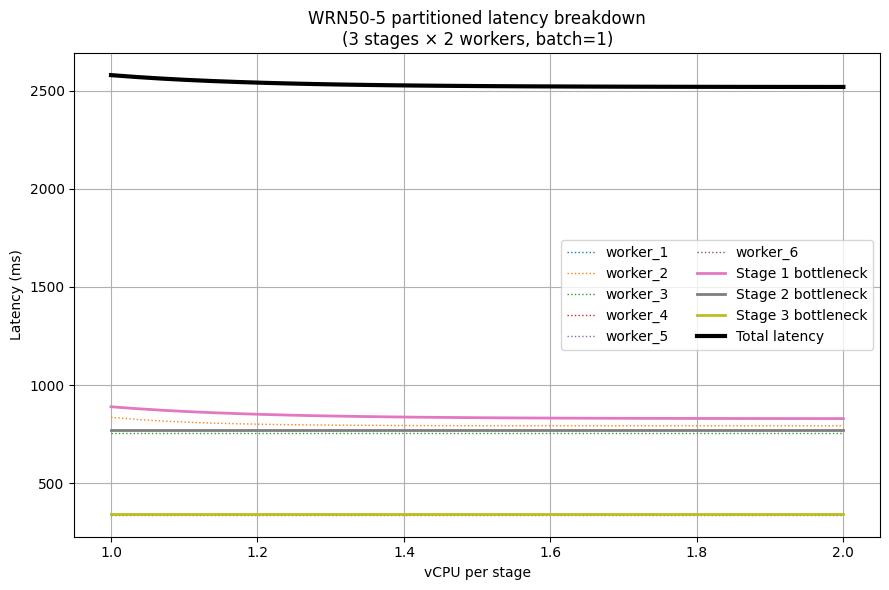

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import math

# -------------------------
# Worker latency parameters (AVG)
# -------------------------
workers = {
    "worker_1": (8710.7085856847,  -4.965280876555562, 828.7367627225481),
    "worker_2": (160829.14103409534, -8.214296178500673, 792.2012988657068),

    "worker_3": (3.6638574314280714e19, -52.712686783211076, 757.875626639285),
    "worker_4": (1.1200159234706186e20, -53.76979225043386, 769.6089448310819),

    "worker_5": (1.327435210162073e18, -49.90572133413484, 341.46355679897647),
    "worker_6": (2.2837813784918252e18, -50.14604029992699, 339.46352127295177),
}

# -------------------------
# Architecture: WRN50-5
# -------------------------
stages = [
    ("worker_1", "worker_2"),
    ("worker_3", "worker_4"),
    ("worker_5", "worker_6"),
]

theta0 = 190.0   # per-stage overhead (ms)
theta1 = 8.0     # per-batch overhead (ms)
batch_size = 1

# -------------------------
# Worker exponential model
# -------------------------
def worker_latency(params, vcpu):
    a, b, c = params
    return a * math.exp(b * vcpu) + c

# -------------------------
# vCPU range
# -------------------------
vcpus = np.linspace(1.0, 2.0, 30)

# -------------------------
# Compute latencies
# -------------------------
worker_curves = {w: [] for w in workers}
stage_curves = [[] for _ in stages]
total_latency = []

for cpu in vcpus:
    stage_latencies = []

    # per-worker
    for w, params in workers.items():
        worker_curves[w].append(worker_latency(params, cpu))

    # per-stage (max worker)
    for i, stage in enumerate(stages):
        lat = max(worker_latency(workers[w], cpu) for w in stage)
        stage_curves[i].append(lat)
        stage_latencies.append(lat)

    # total
    total_latency.append(
        sum(stage_latencies)
        + theta0 * len(stages)
        + theta1 * batch_size
    )

# -------------------------
# Plot
# -------------------------
plt.figure(figsize=(9, 6))

# Workers (thin lines)
for w, vals in worker_curves.items():
    plt.plot(vcpus, vals, linestyle=":", linewidth=1, label=w)

# Stages (medium lines)
for i, vals in enumerate(stage_curves):
    plt.plot(vcpus, vals, linewidth=2, label=f"Stage {i+1} bottleneck")

# Total latency (thick line)
plt.plot(vcpus, total_latency, color="black", linewidth=3, label="Total latency")

plt.xlabel("vCPU per stage")
plt.ylabel("Latency (ms)")
plt.title("WRN50-5 partitioned latency breakdown\n(3 stages × 2 workers, batch=1)")
plt.legend(ncol=2)
plt.grid(True)
plt.tight_layout()
plt.show()


In [4]:
import pandas as pd
import numpy as np
from scipy.optimize import curve_fit
from io import StringIO

# -------------------------
# Load data
# -------------------------
data = "/mnt/data/HarmonyBatch/wrn50_4_partitioned_profiling.csv"
df = pd.read_csv(data)

# -------------------------
# Exponential model
# -------------------------
def exponential(vcpu, a, b, c):
    return a * np.exp(b * vcpu) + c

# -------------------------
# Fit helper
# -------------------------
def fit_worker(df, vcpu_col, latency_col):
    grouped = df.groupby(vcpu_col)[latency_col]

    x = grouped.mean().index.values.astype(float)
    y_avg = grouped.mean().values
    y_p99 = grouped.quantile(0.99).values

    popt_avg, _ = curve_fit(
        exponential,
        x, y_avg,
        maxfev=30000
    )

    popt_p99, _ = curve_fit(
        exponential,
        x, y_p99,
        maxfev=30000
    )

    return popt_avg, popt_p99

# -------------------------
# Fit all workers
# -------------------------
results = {}

for w in [1, 2, 3, 4]:
    avg_params, p99_params = fit_worker(
        df,
        vcpu_col=f"worker{w}_vcpu",
        latency_col=f"worker{w}_latency_ms"
    )
    results[f"worker_{w}"] = {
        "avg": avg_params,
        "max": p99_params
    }

# -------------------------
# Print results
# -------------------------
for w, vals in results.items():
    print(f"\n{w}")
    print("  avg:", vals["avg"])
    print("  p99:", vals["max"])



worker_1
  avg: [-1.80300357e+06  1.38871947e-04  1.80405766e+06]
  p99: [-1.15786991e+06  2.22129547e-04  1.15897615e+06]

worker_2
  avg: [-2.35000000e+06  9.75804934e-05  2.35104756e+06]
  p99: [-1.83948654e+06  1.35870515e-04  1.84062311e+06]

worker_3
  avg: [-4.34462729e+05  1.55440823e-04  4.35082203e+05]
  p99: [-3.22441576e+05  2.38190428e-04  3.23116174e+05]

worker_4
  avg: [-4.45823217e+05  1.90392369e-04  4.46469611e+05]
  p99: [-5.47268927e+05  1.81948136e-04  5.47979091e+05]


AVG parameters for worker1_latency_ms: [14114.52135024786, -5.636024846429723, 548.5782605678877]
AVG parameters for worker2_latency_ms: [9613.308320286786, -4.76363539458628, 565.7723112922941]
AVG parameters for worker3_latency_ms: [11780218607297.023, -33.04065509716449, 508.2368508694687]
AVG parameters for worker4_latency_ms: [147119.22287700674, -8.302828817132715, 481.27585542662956]
AVG parameters for total_latency: [-43318703.59255143, 9.032578644933461e-06, 43321034.81583719]


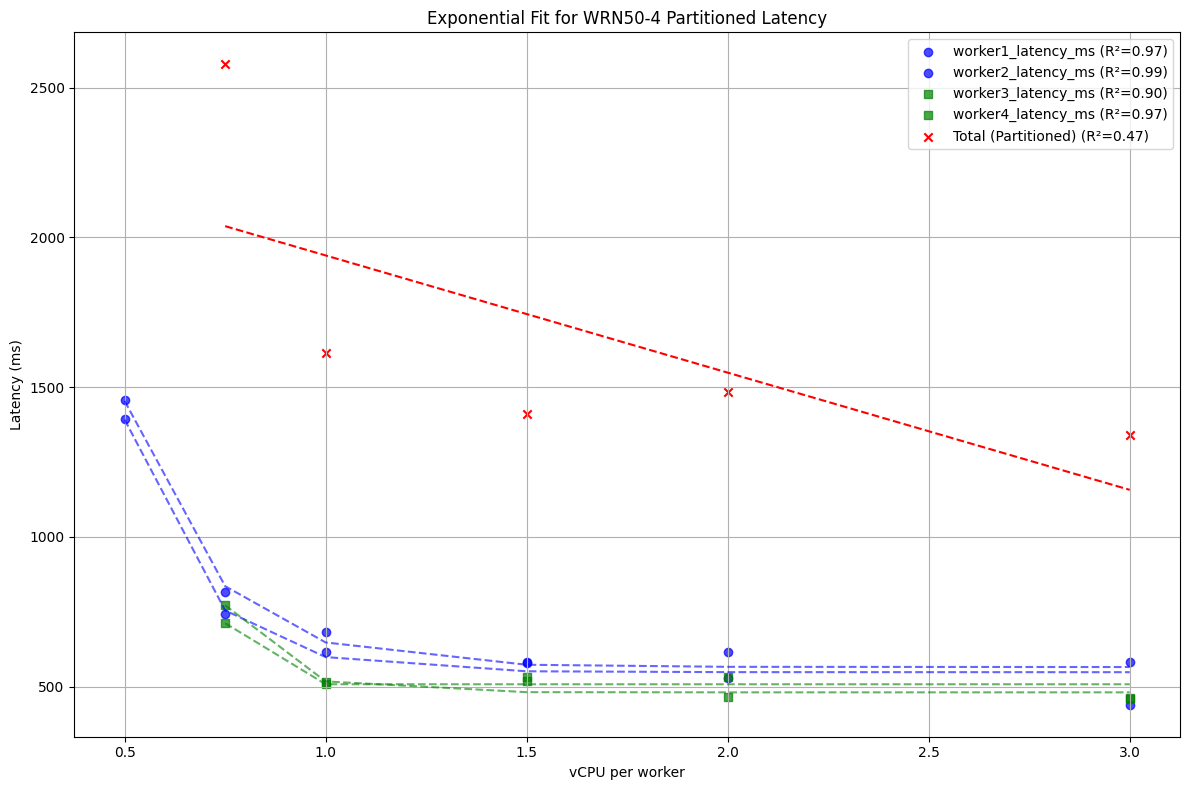

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from sklearn.metrics import r2_score, mean_squared_error

def exponential(x, a, b, c):
    return a * np.exp(b * x) + c


def model_all_latency_sources(
    partitioned_file="/mnt/data/HarmonyBatch/wrn50_4_partitioned_profiling.csv",
    single_file=None,   # optional for WRN50-4
    batch_size=1,
    without_batch=False,
    architecture=None   # <-- NEW: architecture config
):
    """
    Supports WRN50-4 and WRN50-5 via architecture dict:
    architecture = {"stages": 2, "worker_per_stage": 2}
    """

    # -------------------------
    # Load partitioned data
    # -------------------------
    df = pd.read_csv(partitioned_file)

    if without_batch:
        df["batch_size"] = batch_size
    df = df[df["batch_size"] == batch_size] if "batch_size" in df.columns else df

    # -------------------------
    # Architecture (NEW)
    # -------------------------
    if architecture is None:
        architecture = {"stages": 2, "worker_per_stage": 2}  # WRN50-4 default

    stages = architecture["stages"]
    workers_per_stage = architecture["worker_per_stage"]
    total_workers = stages * workers_per_stage

    # -------------------------
    # Build stage map dynamically (NEW)
    # -------------------------
    stage_map = {}
    colors = ["blue", "green", "orange"]
    markers = ["o", "s", "^"]

    w = 1
    for s in range(stages):
        stage_map[f"Stage {s+1}"] = {
            "workers": list(range(w, w + workers_per_stage)),
            "color": colors[s % len(colors)],
            "marker": markers[s % len(markers)],
        }
        w += workers_per_stage

    plt.figure(figsize=(12, 8))

    # -------------------------
    # Plot each worker latency (FIXED vCPU usage)
    # -------------------------
    for stage_label, props in stage_map.items():
        for i in props["workers"]:
            latency_col = f"worker{i}_latency_ms"
            vcpu_col = f"worker{i}_vcpu"

            if latency_col not in df or vcpu_col not in df:
                continue

            df_avg = df.groupby(vcpu_col)[latency_col].max().reset_index()
            X = df_avg[vcpu_col].values
            y = df_avg[latency_col].values

            try:
                params, _ = curve_fit(
                    exponential,
                    X,
                    y,
                    p0=[408278.4321741667, -10.121781301373913, 463.5016554846287],
                    maxfev=20000
                )

                y_pred = exponential(X, *params)
                r2 = r2_score(y, y_pred)
                mse = mean_squared_error(y, y_pred)

                print(f"AVG parameters for {latency_col}: {list(params)}")

                plt.scatter(
                    X, y,
                    label=f"{latency_col} (R²={r2:.2f})",
                    marker=props["marker"],
                    color=props["color"],
                    alpha=0.7
                )
                plt.plot(X, y_pred, linestyle="--", color=props["color"], alpha=0.6)

            except RuntimeError:
                print(f"Fit failed for {latency_col}")

    # -------------------------
    # Plot total partitioned latency (FIXED column name)
    # -------------------------
    if "total_latency_ms" in df.columns:
        df_total = df.groupby(vcpu_col)["total_latency_ms"].max().reset_index()
        X_total = df_total[vcpu_col].values
        y_total = df_total["total_latency_ms"].values

        try:
            params_total, _ = curve_fit(
                exponential,
                X_total,
                y_total,
                p0=[-800000, 0.00015, 1800000],
                maxfev=20000
            )

            y_pred_total = exponential(X_total, *params_total)
            r2_total = r2_score(y_total, y_pred_total)
            mse_total = mean_squared_error(y_total, y_pred_total)

            print("AVG parameters for total_latency:", list(params_total))

            plt.scatter(
                X_total, y_total,
                label=f"Total (Partitioned) (R²={r2_total:.2f})",
                marker="x",
                color="red"
            )
            plt.plot(X_total, y_pred_total, linestyle="--", color="red")

        except RuntimeError as e:
            print(f"Fit failed for total latency: {e}")

    # -------------------------
    # Final plot setup
    # -------------------------
    plt.title("Exponential Fit for WRN50-4 Partitioned Latency")
    plt.xlabel("vCPU per worker")
    plt.ylabel("Latency (ms)")
    plt.grid(True)
    plt.legend(loc="upper right")
    plt.tight_layout()
    plt.show()


# -------------------------
# Run (WRN50-4)
# -------------------------
model_all_latency_sources(
    without_batch=True,
    architecture={"stages": 2, "worker_per_stage": 2}
)


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from sklearn.metrics import r2_score, mean_squared_error

def exponential(x, a, b, c):
    return a * np.exp(b * x) + c


def model_all_latency_sources(
    partitioned_file="/mnt/data/HarmonyBatch/wrn50_4_partitioned_profiling.csv",
    single_file=None,   # optional for WRN50-4
    batch_size=1,
    without_batch=False,
    architecture=None   # <-- NEW: architecture config
):
    """
    Supports WRN50-4 and WRN50-5 via architecture dict:
    architecture = {"stages": 2, "worker_per_stage": 2}
    """

    # -------------------------
    # Load partitioned data
    # -------------------------
    df = pd.read_csv(partitioned_file)

    if without_batch:
        df["batch_size"] = batch_size
    df = df[df["batch_size"] == batch_size] if "batch_size" in df.columns else df

    # -------------------------
    # Architecture (NEW)
    # -------------------------
    if architecture is None:
        architecture = {"stages": 2, "worker_per_stage": 2}  # WRN50-4 default

    stages = architecture["stages"]
    workers_per_stage = architecture["worker_per_stage"]
    total_workers = stages * workers_per_stage

    # -------------------------
    # Build stage map dynamically (NEW)
    # -------------------------
    stage_map = {}
    colors = ["blue", "green", "orange"]
    markers = ["o", "s", "^"]

    w = 1
    for s in range(stages):
        stage_map[f"Stage {s+1}"] = {
            "workers": list(range(w, w + workers_per_stage)),
            "color": colors[s % len(colors)],
            "marker": markers[s % len(markers)],
        }
        w += workers_per_stage

    plt.figure(figsize=(12, 8))

    # -------------------------
    # Plot each worker latency (FIXED vCPU usage)
    # -------------------------
    for stage_label, props in stage_map.items():
        for i in props["workers"]:
            latency_col = f"worker{i}_latency_ms"
            vcpu_col = f"worker{i}_vcpu"

            if latency_col not in df or vcpu_col not in df:
                continue

            df_avg = df.groupby(vcpu_col)[latency_col].max().reset_index()
            X = df_avg[vcpu_col].values
            y = df_avg[latency_col].values

            try:
                params, _ = curve_fit(
                    exponential,
                    X,
                    y,
                    p0=[408278.4321741667, -10.121781301373913, 463.5016554846287],
                    maxfev=20000
                )

                y_pred = exponential(X, *params)
                r2 = r2_score(y, y_pred)
                mse = mean_squared_error(y, y_pred)

                print(f"AVG parameters for {latency_col}: {list(params)}")

                plt.scatter(
                    X, y,
                    label=f"{latency_col} (R²={r2:.2f})",
                    marker=props["marker"],
                    color=props["color"],
                    alpha=0.7
                )
                plt.plot(X, y_pred, linestyle="--", color=props["color"], alpha=0.6)

            except RuntimeError:
                print(f"Fit failed for {latency_col}")

    # -------------------------
    # Plot total partitioned latency (FIXED column name)
    # -------------------------
    if "total_latency_ms" in df.columns:
        df_total = df.groupby(vcpu_col)["total_latency_ms"].max().reset_index()
        X_total = df_total[vcpu_col].values
        y_total = df_total["total_latency_ms"].values

        try:
            params_total, _ = curve_fit(
                exponential,
                X_total,
                y_total,
                p0=[-800000, 0.00015, 1800000],
                maxfev=20000
            )

            y_pred_total = exponential(X_total, *params_total)
            r2_total = r2_score(y_total, y_pred_total)
            mse_total = mean_squared_error(y_total, y_pred_total)

            print("AVG parameters for total_latency:", list(params_total))

            plt.scatter(
                X_total, y_total,
                label=f"Total (Partitioned) (R²={r2_total:.2f})",
                marker="x",
                color="red"
            )
            plt.plot(X_total, y_pred_total, linestyle="--", color="red")

        except RuntimeError as e:
            print(f"Fit failed for total latency: {e}")

    # -------------------------
    # Final plot setup
    # -------------------------
    plt.title("Exponential Fit for WRN50-4 Partitioned Latency")
    plt.xlabel("vCPU per worker")
    plt.ylabel("Latency (ms)")
    plt.grid(True)
    plt.legend(loc="upper right")
    plt.tight_layout()
    plt.show()


# -------------------------
# Run (WRN50-4)
# -------------------------
model_all_latency_sources(
    without_batch=True,
    architecture={"stages": 2, "worker_per_stage": 2}
)


In [46]:
a = [7420.500329521661, 9514.791225762456, -7415.694006506408]
b = [2.6, .82, 2.0]
c= [3.6, .87, 2.9]
d = [4.9, .85, 4.2]
print((list(a), list(np.array(a) * np.array(b)), list(np.array(a) * np.array(c)), list(np.array(a) * np.array(d))))

([7420.500329521661, 9514.791225762456, -7415.694006506408], [19293.30085675632, 7802.128805125213, -14831.388013012816], [26713.801186277982, 8277.868366413337, -21505.512618868583], [36360.451614656144, 8087.572541898087, -31145.914827326917])


    batch_size  vCPU  memory  total_latency
0            1  1.25       5    1979.000000
1            1  1.25       5    1859.000000
3            1  1.25       5    2046.000000
4            1  1.25       5    1942.000000
5            1  1.25       5    1892.000000
6            1  1.25       5    1963.000000
7            1  2.00       5    1872.890234
8            1  2.00       5    1836.538553
10           1  2.00       5    1904.591560
11           1  2.00       5    1858.304977
12           1  2.00       5    1839.600325
13           1  2.00       5    1805.523396
14           1  3.00       5    1639.055729
15           1  3.00       5    1621.168852
16           1  3.00       5    1636.150122
17           1  3.00       5    1624.949455
18           1  3.00       5    1673.553944
19           1  3.00       5    1638.683081
20           1  3.00       5    1611.780643
22           1  3.00       5    1685.999393
23           1  3.00       5    1612.020969
25           1  2.50       5    

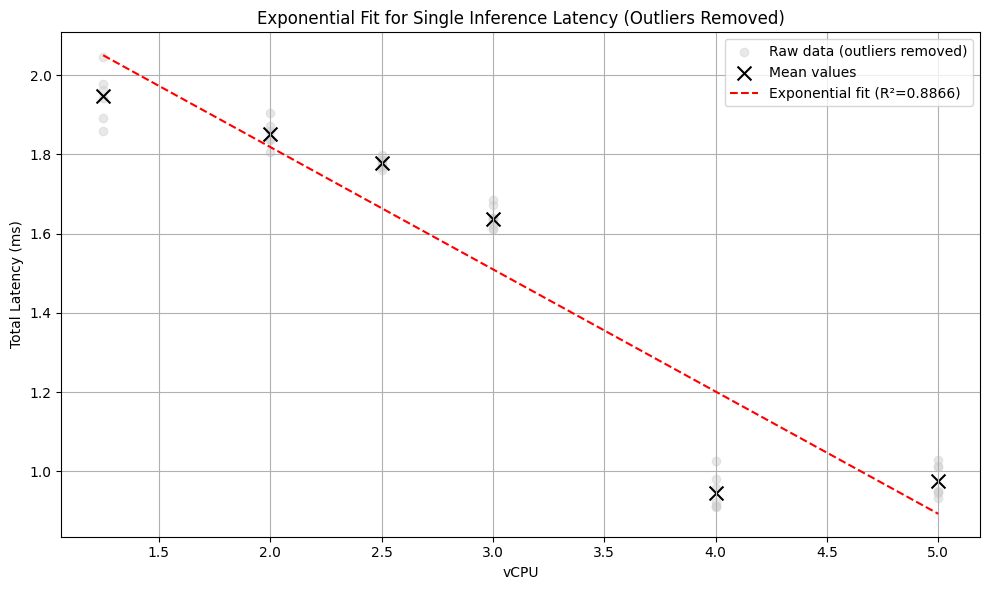

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from sklearn.metrics import r2_score, mean_squared_error
from scipy import stats

def exponential(x, a, b, c):
    return a * np.exp(-x/b) + c

def model_single_inference_latency_no_outliers(file_path='/mnt/data/HarmonyBatch/single_cw4_mx-v2.csv'):
    # Load and group by vCPU
    df = pd.read_csv(file_path)
    
    # Remove outliers using z-score method for each vCPU group
    df_cleaned = pd.DataFrame()
    for vcpu in df['vCPU'].unique():
        group = df[df['vCPU'] == vcpu]
        z_scores = stats.zscore(group['total_latency'])
        group_cleaned = group[abs(z_scores) < 1.3]  # Keep values within 2 standard deviations
        df_cleaned = pd.concat([df_cleaned, group_cleaned])
    print(df_cleaned)
    # Calculate mean latency per vCPU after outlier removal
    df_avg = df_cleaned.groupby('vCPU')['total_latency'].mean().reset_index()
    df_avg = df_avg.sort_values('vCPU')
    
    X = df_avg['vCPU'].values
    y = df_avg['total_latency'].values/1000

    try:
        # Fit exponential model
        params, _ = curve_fit(exponential, X, y, p0=[1600.0, 1.2, 1850.0], maxfev=10000)
        y_pred = exponential(X, *params)
        r2 = r2_score(y, y_pred)
        mse = mean_squared_error(y, y_pred)
        
        # Print parameters
        print('Exponential fit parameters:')
        print(f'[{params[0]:.2f}, {params[1]:.4f}, {params[2]:.2f}]')
        print(f'R² = {r2:.4f}')
        print(f'MSE = {mse:.2f}')

        # Plotting
        plt.figure(figsize=(10, 6))
        
        # Plot original data points
        plt.scatter(df_cleaned['vCPU'], df_cleaned['total_latency']/1000, 
                   color='lightgray', alpha=0.5, label='Raw data (outliers removed)')
        
        # Plot averaged points
        plt.scatter(X, y, color='black', marker='x', s=100, label='Mean values')
        
        # Plot fitted curve
        X_smooth = np.linspace(X.min(), X.max(), 100)
        y_smooth = exponential(X_smooth, *params)
        plt.plot(X_smooth, y_smooth, color='red', linestyle='--', 
                label=f'Exponential fit (R²={r2:.4f})')

        plt.title('Exponential Fit for Single Inference Latency (Outliers Removed)')
        plt.xlabel('vCPU')
        plt.ylabel('Total Latency (ms)')
        plt.grid(True)
        plt.legend()
        plt.tight_layout()
        plt.show()

        return params, r2, mse

    except RuntimeError as e:
        print(f"Fit failed: {e}")
        return None, None, None

# Run the analysis
params, r2, mse = model_single_inference_latency_no_outliers()

In [3]:
import csv

with open('wrn50-5_w6_partitioned_profiling_new_v2.csv', newline='') as f:
    reader = csv.DictReader(f)
    rows = []
    for row in reader:
        # Get worker latencies as floats
        w1 = float(row['worker1_latency_ms'])
        w2 = float(row['worker2_latency_ms'])
        w3 = float(row['worker3_latency_ms'])
        w4 = float(row['worker4_latency_ms'])
        w5 = float(row['worker5_latency_ms'])
        w6 = float(row['worker6_latency_ms'])
        total = float(row['total_latency'])

        # Sum of max latencies for pairs
        pair_sum = max(w1, w2) + max(w3, w4) + max(w5, w6)
        per_stage_overhead = (total - pair_sum) / 3

        # Add new column to row
        row['per_stage_overhead'] = per_stage_overhead
        rows.append(row)

        print(f"Row: total_latency={total}, pair_sum={pair_sum}, per_stage_overhead={per_stage_overhead}")

# Optionally, write to a new CSV with the new column:
with open('wrn50-5_w6_partitioned_profiling_new_v2_with_overhead.csv', 'w', newline='') as f_out:
    fieldnames = rows[0].keys()
    writer = csv.DictWriter(f_out, fieldnames=fieldnames)
    writer.writeheader()
    writer.writerows(rows)

Row: total_latency=2668.0, pair_sum=2120.0, per_stage_overhead=182.66666666666666
Row: total_latency=2573.0, pair_sum=1964.0, per_stage_overhead=203.0
Row: total_latency=2747.0, pair_sum=2267.0, per_stage_overhead=160.0
Row: total_latency=2474.0, pair_sum=1923.0, per_stage_overhead=183.66666666666666
Row: total_latency=2650.0, pair_sum=1919.0, per_stage_overhead=243.66666666666666
Row: total_latency=2475.0, pair_sum=1887.0, per_stage_overhead=196.0
Row: total_latency=2529.0, pair_sum=1877.0, per_stage_overhead=217.33333333333334
Row: total_latency=2412.0, pair_sum=1876.0, per_stage_overhead=178.66666666666666
Row: total_latency=2430.0, pair_sum=1938.0, per_stage_overhead=164.0
Row: total_latency=2588.0, pair_sum=2037.0, per_stage_overhead=183.66666666666666
Row: total_latency=2634.0, pair_sum=2037.0, per_stage_overhead=199.0
Row: total_latency=2468.0, pair_sum=1998.0, per_stage_overhead=156.66666666666666
Row: total_latency=2590.0, pair_sum=2059.0, per_stage_overhead=177.0
Row: total_l

In [8]:
import pandas as pd
oh_df = pd.read_csv('wrn50-5_w6_partitioned_profiling_new_v2_with_overhead.csv')
# oh_df['per_stage_overhead']
oh_df.groupby('worker6_vcpu')['per_stage_overhead'].mean().reset_index()

,worker6_vcpu,per_stage_overhead
0,0.75,177.000000
1,1.00,175.757576
2,1.50,191.266667
3,2.00,178.633333


### Cost Analysis

In [38]:
import pandas as pd
from harmony.core.cost import FunctionCost # Adjust import if needed

from harmony.core.util import Instance
# import cost

# Load your CSV
file_path = "/mnt/data/HarmonyBatch/Partitioned_Latency_with_Batch_Size.csv"
# '/mnt/data/HarmonyBatch/wrn50_cpu_profiling_batch1_all_configs.csv'
single_path = '/mnt/data/HarmonyBatch/wrn50_single_inference_latency.csv'
cost_df = pd.read_csv(file_path)
single_df = pd.read_csv(single_path)
# Define the batch size used
batch_size = 2
single_df = single_df[single_df['batch_size'] == batch_size]
cost_df = cost_df[cost_df['batch_size'] == batch_size]
# Function to calculate cost row-wise
def compute_cost(row):
    total_latency = row['total_latency']
    worker_latencies = [row[f'worker_{i}'] for i in range(1, 13)]

    # Create instance objects
    master_instance = Instance(
        row['master_vCPU'],
        int(row['master_memory']),
        0
    )
    
    worker_instance = Instance(
        row['workers_vCPU'],
        float(row['workers_memory']),
        0
    )

    worker_instances = [worker_instance] * 12  # 12 workers
    fc = FunctionCost()
    # Compute and return cost
    return fc.calculate_total_cost_with_workers(
        total_latency,
        worker_latencies,
        batch_size,
        master_instance,
        worker_instances,
        True
    )

def compute_single_cost(row, memory_gb = 2):
    total_latency = row['total_latency']
    vcpu = row['vCPU']
    
    instance = Instance(vcpu, memory_gb, 0)
    fc = FunctionCost()
    return fc.cost(
        total_latency/1000,
        batch_size,
        instance,          # master = function itself
        True
    )

# Apply to DataFrame
cost_df['cost'] = cost_df.apply(compute_cost, axis=1)

single_df['cost'] = single_df.apply(compute_single_cost, axis=1)

# Save updated CSV
cost_df.to_csv('wrn50_cpu_profiling_batch1_all_configs_with_cost.csv', index=False)
single_df.to_csv('wrn50_single_inference_latency_with_cost.csv', index=False)
# single_grouped_cost = single_df.groupby('vCPU')['cost'].mean().reset_index()
# grouped_cost = cost_df.groupby('workers_vCPU')['cost'].mean().reset_index()
# print(cost_df)


In [1]:
# --- minimal-changes cost script for your current setup (6 workers) ---

import pandas as pd

# Your original imports (unchanged; adjust the import paths only if your codebase differs)
from harmony.core.cost import FunctionCost   # Adjust import if needed in *your* project
from harmony.core.util import Instance       # Adjust import if needed

# -----------------------------
# INPUT FILES (set to your paths)
# -----------------------------
# Partitioned profiling CSV (the one we built with 6 workers and per-worker columns)
partitioned_path = "/mnt/data/HarmonyBatch/wrn50-5_w6_partitioned_profiling_new_v2.csv"

# Single-inference profiling CSV (your own file)
single_path = "/mnt/data/HarmonyBatch/singlemx_wrn50-4.csv"

# -----------------------------
# CONFIG
# -----------------------------
NUM_WORKERS = 6

# Only used if your single-inference CSV doesn't carry memory; preserves your original default.
DEFAULT_SINGLE_MEMORY_GB = 2

# Only filter by batch if the CSVs actually contain that column (no assumptions).
BATCH_SIZE_FILTER = 1

# -----------------------------
# LOAD
# -----------------------------
part_df = pd.read_csv(partitioned_path)
single_df = pd.read_csv(single_path)

# -----------------------------
# OPTIONAL FILTER by batch_size (only if column exists)
# -----------------------------
if "batch_size" in part_df.columns:
    part_df = part_df[part_df["batch_size"] == BATCH_SIZE_FILTER].copy()

if "batch_size" in single_df.columns:
    single_df = single_df[single_df["batch_size"] == BATCH_SIZE_FILTER].copy()

# -----------------------------
# COST FUNCTIONS
# -----------------------------
def compute_partitioned_cost(row):
    """
    Minimal change from your original logic, adapted to your 6-worker CSV:
      - master vCPU/memory from: master_vcpu, master_memory_gb
      - per-worker vCPU/memory from: worker{i}_vcpu, worker{i}_memory_gb
      - worker latencies from: worker{i}_latency_ms
      - total latency from: total_latency_ms (keeps your original units behavior)
    """
    # total latency: keep your original behavior (do NOT modify units here)
    total_latency = row["total_latency_ms"]

    # worker latencies (W1..W6)
    worker_latencies = [row[f"worker{i}_latency_ms"] for i in range(1, NUM_WORKERS + 1)]

    # master instance (from your CSV column names)
    master_instance = Instance(
        float(row["master_vcpu"]),
        float(row["master_memory_gb"]),
        0
    )

    # per-worker instances (per the current CSV: each worker can differ)
    worker_instances = []
    for i in range(1, NUM_WORKERS + 1):
        vcpu = float(row[f"worker{i}_vcpu"])
        mem_gb = float(row[f"worker{i}_memory_gb"])
        worker_instances.append(Instance(vcpu, mem_gb, 0))

    fc = FunctionCost()

    # Keep your original call signature; do not change flags/units.
    # NOTE: Your original code passed 'total_latency' directly for the partitioned case.
    #       I'm preserving that exactly to avoid changing semantics.
    return fc.calculate_total_cost_with_workers(
        total_latency,        # unchanged from your code
        worker_latencies,
        BATCH_SIZE_FILTER if "batch_size" in row.index else 1,  # preserve your original idea if present
        master_instance,
        worker_instances,
        True
    )


def compute_single_cost(row, memory_gb=DEFAULT_SINGLE_MEMORY_GB):
    """
    Single-inference cost; preserves your original behavior:
      - total latency divided by 1000
      - vCPU from 'vCPU' column in your single CSV
      - memory default = 2 GB unless your single CSV carries memory
    """
    total_latency = row["total_latency"]  # expecting this name in your single CSV (unchanged from your snippet)
    vcpu = float(row["vCPU"])

    # If single CSV has memory, prefer it; otherwise use default.
    mem_gb = float(row["memory_gb"]) if "memory_gb" in row.index else float(memory_gb)

    instance = Instance(vcpu, mem_gb, 0)
    fc = FunctionCost()

    return fc.cost(
        total_latency / 1000.0 + 0.1,                         # unchanged: convert ms -> s (your original code)
        BATCH_SIZE_FILTER if "batch_size" in row.index else 1,
        instance,
        True
    )

# -----------------------------
# APPLY
# -----------------------------
part_df = part_df.copy()
part_df["cost"] = part_df.apply(compute_partitioned_cost, axis=1)

single_df = single_df.copy()
single_df["cost"] = single_df.apply(compute_single_cost, axis=1)

# -----------------------------
# SAVE
# -----------------------------
# Keep the same naming convention as your originals, just adapted to these inputs.
part_out = partitioned_path.replace(".csv", "_with_cost1.csv")
single_out = single_path.replace(".csv", "_with_cost1.csv")

part_df.to_csv(part_out, index=False)
# single_df.to_csv(single_out, index=False)

print(f"[OK] Wrote partitioned with cost: {part_out}")
print(f"[OK] Wrote single with cost:     {single_out}")


Harmony
[OK] Wrote partitioned with cost: /mnt/data/HarmonyBatch/wrn50-5_w6_partitioned_profiling_new_v2_with_cost1.csv
[OK] Wrote single with cost:     /mnt/data/HarmonyBatch/singlemx_wrn50-4_with_cost1.csv


In [3]:
single_df = pd.read_csv('/mnt/data/HarmonyBatch/wrn50_4_partitioned_profiling_with_cost1.csv')
single_cost_latency = single_df.groupby('vCPU')[['cost', 'total_latency']].mean().reset_index()
mp_cost_latency = part_df.groupby('worker6_vcpu')[['cost', 'total_latency_ms']].mean().reset_index()
print(single_cost_latency)
print(mp_cost_latency)

KeyError: 'vCPU'

In [ ]:
single_df = pd.read_csv('/mnt/data/HarmonyBatch/wrn50-4_single_mxnet_with_cost1.csv')
single_cost_latency = single_df.groupby('vCPU')[['cost', 'total_latency']].mean().reset_index()
mp_cost_latency = part_df.groupby('worker6_vcpu')[['cost', 'total_latency_ms']].mean().reset_index()
print(single_cost_latency)
print(mp_cost_latency)

   vCPU      cost  total_latency
0   1.5  0.000108         2749.0
1   2.0  0.000125         2716.0
   worker6_vcpu      cost  total_latency_ms
0          0.75  0.000130       3469.444444
1          1.00  0.000108       2396.250000
2          1.50  0.000152       2631.166667
3          2.00  0.000186       2701.285714


In [40]:
mp_cost_latency[['workers_vCPU', 'cost', 'total_latency']]

,workers_vCPU,cost,total_latency
0,0.50,0.000124,4708.500000
1,0.75,0.000094,3172.333333
2,1.00,0.000084,2437.000000
3,1.50,0.000110,2449.500000
4,2.00,0.000113,2148.333333


In [41]:
single_cost_latency[['vCPU', 'cost', 'total_latency']]

,vCPU,cost,total_latency
0,0.50,0.000077,12060.666667
1,0.75,0.000064,7586.666667
2,1.00,0.000051,4945.666667
3,1.50,0.000049,3369.000000
4,2.00,0.000046,2481.333333


/tmp/ipykernel_1357326/4197569545.py:45: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('YlOrRd')


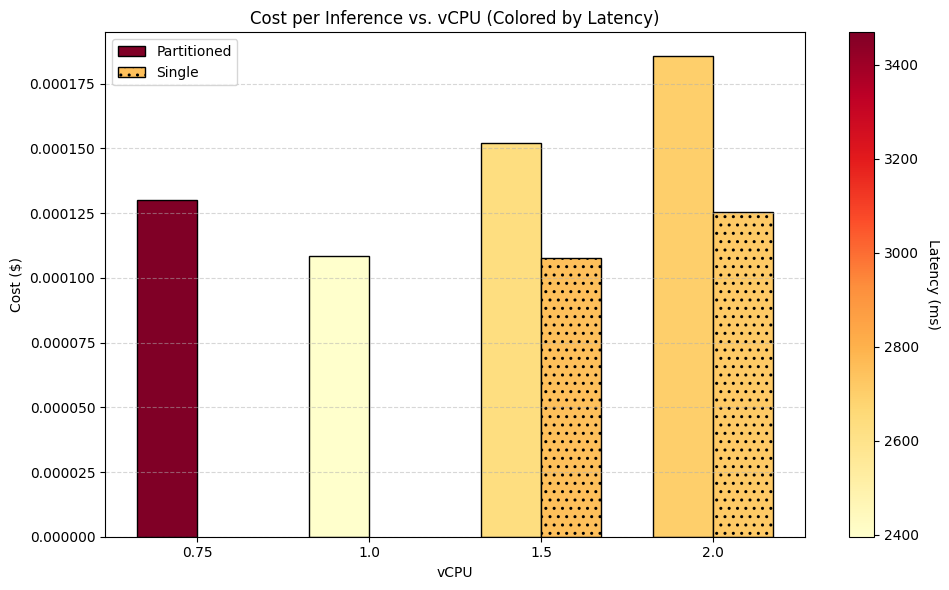

In [21]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.cm as cm
import matplotlib.colors as mcolors

def plot_cost_comparison_with_latency_heat(df_partitioned, df_single):
    # Columns
    vcpu_col_part = 'worker6_vcpu'
    vcpu_col_single = 'vCPU'

    # Aggregate by vCPU (mean) to handle multiple rows per setting
    part_g = df_partitioned.groupby(vcpu_col_part, as_index=False).agg(
        cost=('cost', 'mean'),
        total_latency_ms=('total_latency_ms', 'mean')
    )
    sing_g = df_single.groupby(vcpu_col_single, as_index=False).agg(
        cost=('cost', 'mean'),
        total_latency=('total_latency', 'mean')
    )

    # Use the UNION of vCPU values (not just the intersection)
    vcpus_all = sorted(set(part_g[vcpu_col_part].values) | set(sing_g[vcpu_col_single].values))
    index = np.arange(len(vcpus_all))
    bar_width = 0.35

    # Map vCPU -> values
    part_cost_map = dict(zip(part_g[vcpu_col_part], part_g['cost']))
    part_lat_map  = dict(zip(part_g[vcpu_col_part], part_g['total_latency_ms']))

    sing_cost_map = dict(zip(sing_g[vcpu_col_single], sing_g['cost']))
    sing_lat_map  = dict(zip(sing_g[vcpu_col_single], sing_g['total_latency']))

    # Build aligned arrays (NaN for missing single entries)
    cost_partitioned     = np.array([part_cost_map[v]  if v in part_cost_map else np.nan for v in vcpus_all], dtype=float)
    latency_partitioned  = np.array([part_lat_map[v]   if v in part_lat_map  else np.nan for v in vcpus_all], dtype=float)
    cost_single          = np.array([sing_cost_map.get(v, np.nan) for v in vcpus_all], dtype=float)
    latency_single       = np.array([sing_lat_map.get(v, np.nan)  for v in vcpus_all], dtype=float)

    # Normalize colors using only finite latency values
    finite_lat = np.concatenate([latency_partitioned[np.isfinite(latency_partitioned)],
                                 latency_single[np.isfinite(latency_single)]])
    vmin = finite_lat.min()
    vmax = finite_lat.max()
    norm = mcolors.Normalize(vmin=vmin, vmax=vmax)
    cmap = cm.get_cmap('YlOrRd')

    fig, ax = plt.subplots(figsize=(10, 6))

    # Partitioned bars: draw for ALL vCPUs (they all exist in your partitioned data)
    colors_part = cmap(norm(np.nan_to_num(latency_partitioned, nan=vmin)))
    ax.bar(index - bar_width/2, cost_partitioned, bar_width,
           color=colors_part, hatch='', edgecolor='black', label='Partitioned')

    # Single bars: draw only where single exists (mask out NaNs)
    mask_single = np.isfinite(cost_single)
    if mask_single.any():
        colors_single = cmap(norm(latency_single[mask_single]))
        ax.bar(index[mask_single] + bar_width/2, cost_single[mask_single], bar_width,
               color=colors_single, hatch='..', edgecolor='black', label='Single')

    ax.set_xlabel('vCPU')
    ax.set_ylabel('Cost ($)')
    ax.set_title('Cost per Inference vs. vCPU (Colored by Latency)')
    ax.set_xticks(index)
    ax.set_xticklabels([str(v) for v in vcpus_all])
    ax.legend()

    # Colorbar for latency
    sm = cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax)
    cbar.set_label('Latency (ms)', rotation=270, labelpad=15)

    plt.tight_layout()
    plt.grid(True, axis='y', linestyle='--', alpha=0.5)
    plt.show()
plot_cost_comparison_with_latency_heat(mp_cost_latency, single_cost_latency)

/tmp/ipykernel_1005759/2395488300.py:22: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('YlOrRd')


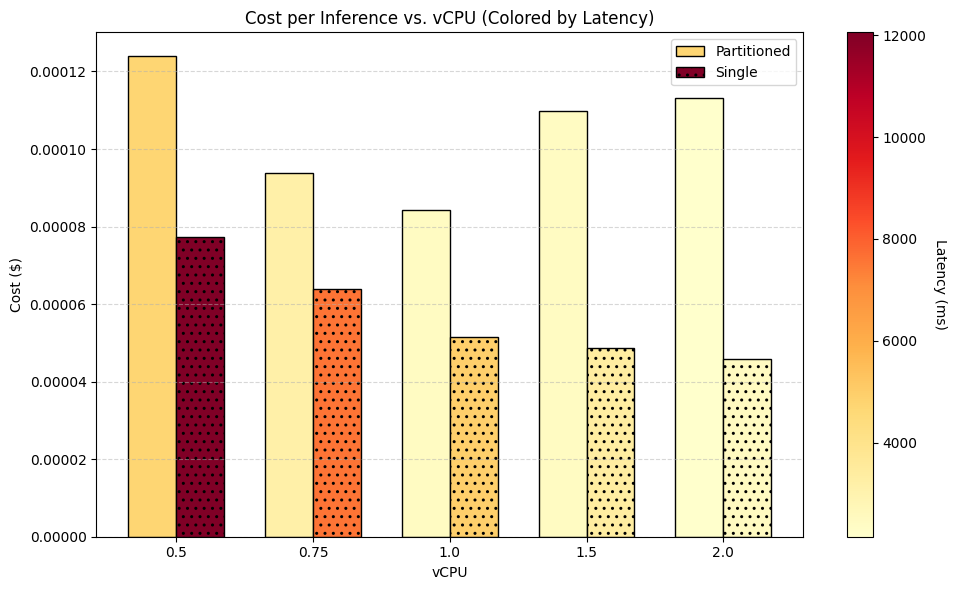

In [42]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.cm as cm
import matplotlib.colors as mcolors

def plot_cost_comparison_with_latency_heat(df_partitioned, df_single):
    df_partitioned = df_partitioned.sort_values('workers_vCPU')
    df_single = df_single.sort_values('vCPU')
    
    vcpus = df_partitioned['workers_vCPU'].values
    bar_width = 0.35
    index = np.arange(len(vcpus))

    cost_partitioned = df_partitioned['cost'].values
    cost_single = df_single['cost'].values
    latency_partitioned = df_partitioned['total_latency'].values
    latency_single = df_single['total_latency'].values

    # Normalize latency values for color mapping
    all_latencies = np.concatenate([latency_partitioned, latency_single])
    norm = mcolors.Normalize(vmin=all_latencies.min(), vmax=all_latencies.max())
    cmap = cm.get_cmap('YlOrRd')

    fig, ax = plt.subplots(figsize=(10, 6))

    # Plot bars with color from latency and hatch pattern for style
    bars1 = ax.bar(index - bar_width/2, cost_partitioned, bar_width,
               color=cmap(norm(latency_partitioned)),
               hatch='',               # criss-cross
               edgecolor='black',
               label='Partitioned')

    bars2 = ax.bar(index + bar_width/2, cost_single, bar_width,
               color=cmap(norm(latency_single)),
               hatch='..',               # dotted
               edgecolor='black',
               label='Single')

    ax.set_xlabel('vCPU')
    ax.set_ylabel('Cost ($)')
    ax.set_title('Cost per Inference vs. vCPU (Colored by Latency)')
    ax.set_xticks(index)
    ax.set_xticklabels([str(v) for v in vcpus])
    ax.legend()

    # Colorbar for latency
    sm = cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax)
    cbar.set_label('Latency (ms)', rotation=270, labelpad=15)

    plt.tight_layout()
    plt.grid(True, axis='y', linestyle='--', alpha=0.5)
    plt.show()


plot_cost_comparison_with_latency_heat(mp_cost_latency, single_cost_latency)


[5140.135005988766, -3.2442882816610523, 1643.4077027541514]

Exponential Regression Results:
MSE: 896.297211937449
R²: 0.9935289025543591


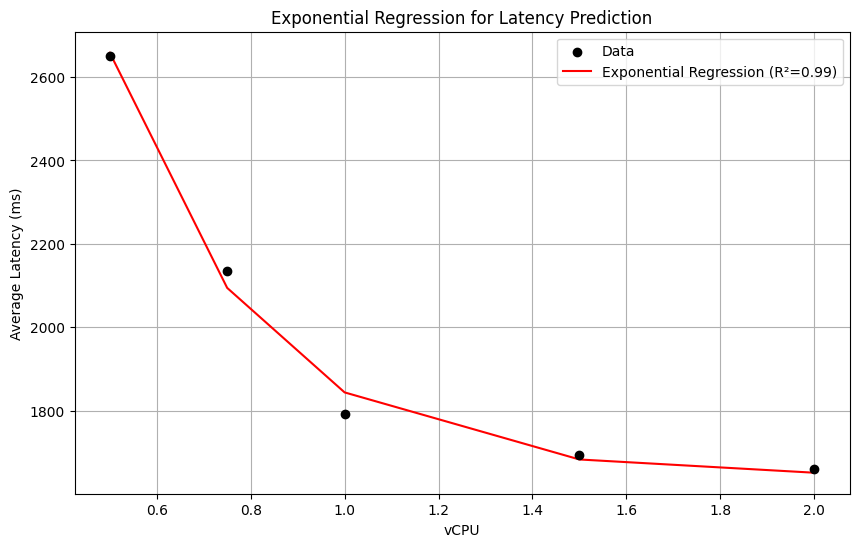

In [40]:
avg_fit_exponential(attribute="total_latency")

NameError: name 'curve_fit' is not defined

In [15]:
params

array([2784.48385955,   -4.43692924,  500.53192111])

In [6]:
df_min_mem_latency = df.loc[df.groupby('vCPU')['Memory'].idxmin()].groupby('vCPU').apply(lambda x: x.loc[x['Min_latency(ms)'].idxmin()])
df_min_mem_latency

/tmp/ipykernel_813562/3329862725.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_min_mem_latency = df.loc[df.groupby('vCPU')['Memory'].idxmin()].groupby('vCPU').apply(lambda x: x.loc[x['Min_latency(ms)'].idxmin()])


,vCPU,Memory,Batch_size,Avg_latency(ms),Min_latency(ms),Max_latency(ms),Count,Total_cost($)
vCPU,,,,,,,,
0.35,0.35,512.0,1.0,1250.666667,1077.0,1746.0,9.0,0.005746
0.50,0.50,512.0,1.0,1206.555556,828.0,2089.0,9.0,0.007690
0.75,0.75,1024.0,1.0,979.222222,581.0,1867.0,9.0,0.011362
1.00,1.00,1024.0,1.0,885.000000,540.0,1904.0,9.0,0.014602
1.50,1.50,2048.0,1.0,956.222222,519.0,1955.0,9.0,0.022378
2.00,2.00,2048.0,1.0,1024.777778,512.0,2118.0,9.0,0.029074


In [6]:
prof = pd.read_csv('/mnt/data/HarmonyBatch/wrn50_cpu_profiling_batch1_all_configs.csv')
prof

,model,batch_size,workers_vCPU,workers_memory,master_vCPU,master_memory,worker_1,worker_2,worker_3,worker_4,...,worker_6,worker_7,worker_8,worker_9,worker_10,worker_11,worker_12,total_latency,overhead_raw,overhead_per_stage
0,WRN-50-4,1,0.50,2048mb,0.5,2048mb,709,708,752,842,...,225,278,270,452,435,394,432,2451,879,293.000000
1,WRN-50-4,1,0.50,2048mb,0.5,2048mb,832,813,756,776,...,225,272,320,404,460,387,453,2471,856,285.333333
2,WRN-50-4,1,0.50,2048mb,0.5,2048mb,857,796,885,715,...,266,220,299,398,419,498,419,2505,823,274.333333
3,WRN-50-4,1,0.50,2048mb,0.5,2048mb,809,774,925,938,...,209,265,304,438,450,553,582,2650,826,275.333333
4,WRN-50-4,1,0.50,2048mb,0.5,2048mb,760,837,800,670,...,238,241,308,444,365,406,485,2534,904,301.333333
5,WRN-50-4,1,0.75,2048mb,0.5,2048mb,513,460,408,418,...,141,163,209,263,224,225,272,2034,1040,346.666667
6,WRN-50-4,1,0.75,2048mb,0.5,2048mb,420,606,397,452,...,142,136,141,247,259,230,258,2135,1124,374.666667
7,WRN-50-4,1,0.75,2048mb,0.5,2048mb,505,471,426,455,...,142,115,151,216,212,204,230,1774,888,296.000000
8,WRN-50-4,1,0.75,2048mb,0.5,2048mb,419,537,409,514,...,130,198,153,223,280,217,296,1866,835,278.333333
9,WRN-50-4,1,0.75,2048mb,0.5,2048mb,570,389,424,534,...,179,159,137,306,270,199,229,1944,889,296.333333


In [5]:
from latency import UnifiedLatency

# Example usage: batch size 1, average model
model = UnifiedLatency(config_path="config.json", batch_size=1, model_type="avg")

# Predict total latency for 1.0 vCPU
total_latency = model.lat(vcpu=1.0)
print(f"Predicted total avg latency (1.0 vCPU): {total_latency:.2f} ms")

# Predict latency for worker 3 (example)
worker_latency = model.lat(vcpu=1.0, worker_id=3)
print(f"Predicted avg latency of worker 3 (1.0 vCPU): {worker_latency:.2f} ms")

ModuleNotFoundError: No module named 'harmony'